In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib

# Load
data_path = Path("../../datasets/teleco/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(data_path)

# Perform raw parsing (from Notebook 1 cleaning step)
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df['TotalCharges'] = df['TotalCharges'].astype(float)

print(f"Data reloaded. Shape: {df.shape}")


Data reloaded. Shape: (7043, 21)


In [2]:
# Check count of missing values
print(f"Nulls before handling:\n{df.isnull().sum()}\n")

# Verify which rows are null. (Notice tenure is 0 for all of them)
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])

# Impute missing TotalCharges with 0 since tenure is 0 (service hasn't started yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Check missing values again
print(f"\nNulls after handling: {df['TotalCharges'].isnull().sum()}")


Nulls before handling:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754   

In [3]:
# Convert SeniorCitizen from numeric 0/1 to categorical 'No'/'Yes' for encoding consistency
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'}).astype('category')

# Confirm correct schemas
print(df[['SeniorCitizen', 'TotalCharges']].dtypes)


SeniorCitizen    category
TotalCharges      float64
dtype: object


In [4]:
# Convert Churn target (Yes/No) to (1/0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Target variable frequencies:")
print(df['Churn'].value_counts())


Target variable frequencies:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
# customerID is not predictive, drop it
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Identify binary columns (2 unique values) vs multi-category columns
# Identify binary columns (2 unique values) vs multi-category columns
binary_cols = []
multi_cols = []

for col in df.columns:
    if col != 'Churn':
        n_unique = df[col].nunique()
        if n_unique == 2:
            binary_cols.append(col)
        elif df[col].dtype.name in ['object', 'category', 'string', 'str']:  # Updated Check
            multi_cols.append(col)

print(f"Binary Features: {binary_cols}")
print(f"Multi-Category Features: {multi_cols}")

# Label Encode Binary Columns
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-Hot Encode Multi-Category Columns
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f"\nEncoded dataset shape: {df.shape}")
df.head()


Binary Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'TenureBucket_Loyal', 'TenureBucket_New', 'MonthlyChargeBucket_Medium', 'MonthlyChargeBucket_High']
Multi-Category Features: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Encoded dataset shape: (7043, 37)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [6]:
# 1. Average Monthly Spend (handle divide-by-zero risk with tenure + 1)
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# 2. Customer Age Bucket based on tenure
def get_tenure_bucket(t):
    if t <= 12:
        return 'New'
    elif t <= 48:
        return 'Growing'
    else:
        return 'Loyal'

# Map and perform one-hot encoding on the resulting category
df['TenureBucket'] = df['tenure'].apply(get_tenure_bucket)
df = pd.get_dummies(df, columns=['TenureBucket'], drop_first=True)

# 3. Monthly Charge Bucket (Low, Medium, High) using quartile cuts
df['MonthlyChargeBucket'] = pd.qcut(df['MonthlyCharges'], q=3, labels=['Low', 'Medium', 'High'])
df = pd.get_dummies(df, columns=['MonthlyChargeBucket'], drop_first=True)

# 4. Services Count
# To get service counts, locate the one-hot encoded columns matching the active services.
# The original features were: OnlineSecurity, OnlineBackup, TechSupport, DeviceProtection, StreamingTV, StreamingMovies.
# One-hot suffixes for 'Yes' columns:
service_cols = [
    'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 
    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes'
]

# Check existing columns matching these services in our encoded DataFrame
active_services = [c for c in service_cols if c in df.columns]
df['ServicesCount'] = df[active_services].sum(axis=1)

print("Engineered Features Summary:")
df[['AvgMonthlySpend', 'ServicesCount']].head()


Engineered Features Summary:


,AvgMonthlySpend,ServicesCount
0,14.925000,0.0
1,53.985714,0.0
2,36.050000,0.0
3,40.016304,0.0
4,50.550000,0.0


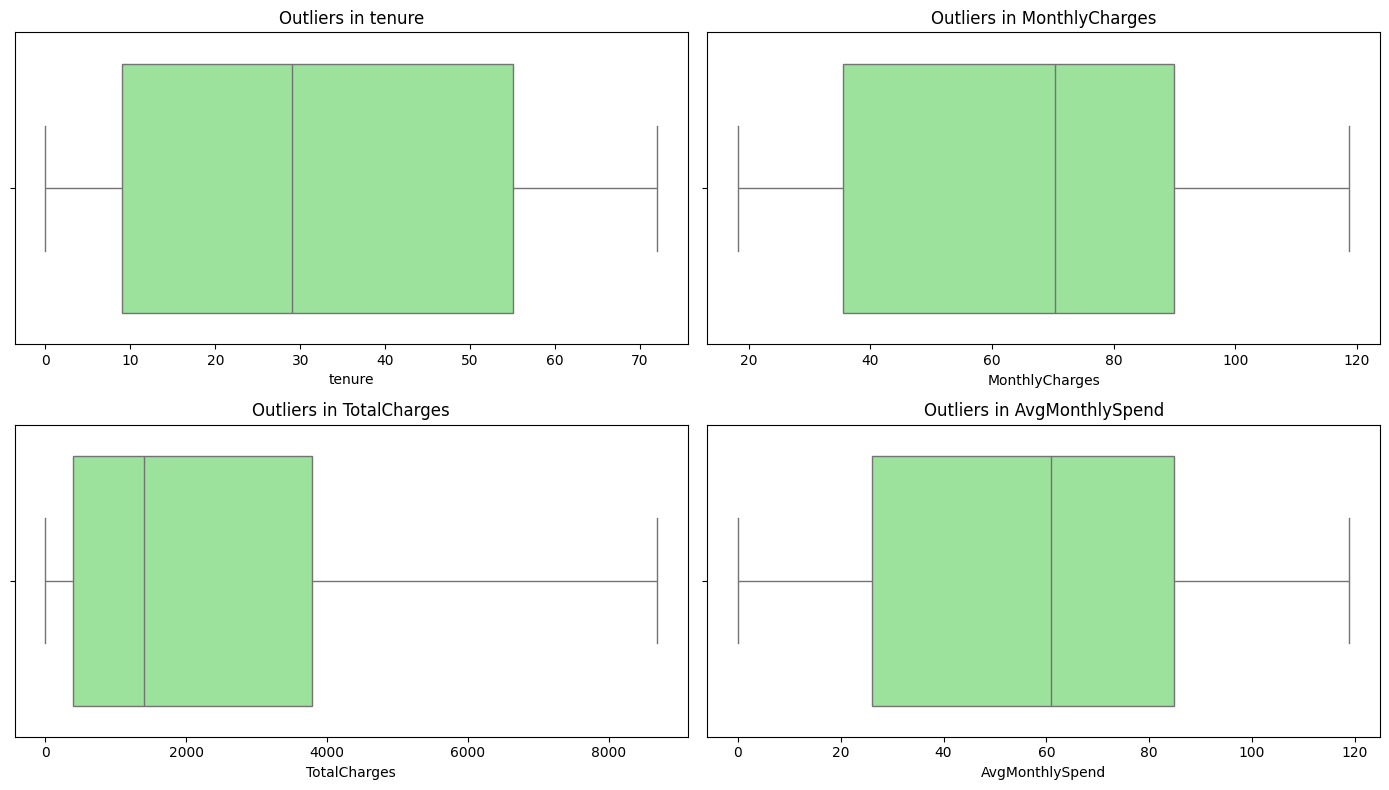

tenure: Found 0 outliers using IQR standard (Lower: -60.00, Upper: 124.00)
MonthlyCharges: Found 0 outliers using IQR standard (Lower: -46.02, Upper: 171.38)
TotalCharges: Found 0 outliers using IQR standard (Lower: -4683.52, Upper: 8868.67)
AvgMonthlySpend: Found 0 outliers using IQR standard (Lower: -62.14, Upper: 173.01)


In [12]:
# Draw boxplots to visualize outliers in numerical fields
num_feats = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']

plt.figure(figsize=(14, 8))
for idx, col in enumerate(num_feats, 1):
    plt.subplot(2, 2, idx)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

# Perform IQR Check
for col in num_feats:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: Found {len(outliers)} outliers using IQR standard (Lower: {lower_bound:.2f}, Upper: {upper_bound:.2f})")


In [13]:
X = df.drop(columns=['Churn'])
y = df['Churn']

# 80/20 Stratified Split to preserve label ratios
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"X_train Shape: {X_train.shape}, y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape}, y_test Shape: {y_test.shape}")


X_train Shape: (5634, 36), y_train Shape: (5634,)
X_test Shape: (1409, 36), y_test Shape: (1409,)


In [14]:
# Identify true numerical metrics
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'ServicesCount']

scaler = StandardScaler()

# Scaling only the numerical columns to preserve dummy features (0/1) structure
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Convert dummy variables (boolean) to float/int to prevent matrix format warning in ML algorithms
bool_cols = X_train_scaled.select_dtypes(include=['bool']).columns
X_train_scaled[bool_cols] = X_train_scaled[bool_cols].astype(int)
X_test_scaled[bool_cols] = X_test_scaled[bool_cols].astype(int)

# Check statistics after scaling
X_train_scaled[numerical_cols].describe().round(3)


,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,ServicesCount
count,5634.000,5634.000,5634.000,5634.000,5634.0
mean,-0.000,-0.000,0.000,0.000,0.0
std,1.000,1.000,1.000,1.000,0.0
min,-1.322,-1.544,-1.009,-1.933,0.0
25%,-0.956,-0.971,-0.832,-1.075,0.0
50%,-0.142,0.185,-0.397,0.067,0.0
75%,0.916,0.832,0.674,0.850,0.0
max,1.608,1.786,2.802,1.951,0.0


In [15]:
# Analyze class distribution before SMOTE
print("Class distribution before SMOTE:")
print(y_train.value_counts(normalize=True))

# Initialize and apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Analyze class distribution after SMOTE
print("\nClass distribution after SMOTE:")
print(y_train_res.value_counts(normalize=True))


Class distribution before SMOTE:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Class distribution after SMOTE:
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


In [16]:
# Save clean splits for Model Building
processed_data = {
    'X_train': X_train_res,
    'X_test': X_test_scaled,
    'y_train': y_train_res,
    'y_test': y_test,
    'scaler': scaler,
    'features': X_train.columns.tolist()
}

# Save using joblib
joblib.dump(processed_data, 'processed_churn_data.pkl')
print("Processed objects saved successfully to 'processed_churn_data.pkl'!")


Processed objects saved successfully to 'processed_churn_data.pkl'!
